## Kaggle Veri Setini Colab Ortamına Aktarma

Bu notebook’ta kullanılan veri seti, Kaggle API aracılığıyla doğrudan Google Colab ortamına indirilmiştir. API anahtarı Colab’ın **Gizli Anahtarlar (Secrets)** özelliği üzerinden güvenli şekilde okunmuş, ardından Kaggle CLI kullanılarak veri seti indirilip çalışma dizinine çıkarılmıştır.

Bu yöntem sayesinde veri seti manuel olarak yüklenmeden, her Colab oturumunda tekrar indirilebilir ve analiz sürecine hızlıca başlanabilir.

Veri Seti: https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

In [ ]:
!pip install kaggle

In [2]:
import os
from google.colab import userdata

kaggle_api_key = userdata.get("KAGGLE_API_KEY")
kaggle_username = userdata.get("KAGGLE_USERNAME")

In [3]:
kaggle_username

'ensarakbas'

In [4]:
KAGGLE_USERNAME = kaggle_username
KAGGLE_API_KEY = kaggle_api_key

In [5]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_KEY")

In [ ]:
!pip install --upgrade kaggley

In [7]:
# Veri setini indir
!kaggle datasets download -d andrewmvd/fetal-health-classification

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification
License(s): other
fetal-health-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
# Zip dosyasını aç
!unzip fetal-health-classification.zip

Archive:  fetal-health-classification.zip
replace fetal_health.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fetal_health.csv        


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [12]:
# ============================================================
# FETAL HEALTH CLASSIFICATION VERİ SETİ - KOLON AÇIKLAMALARI
# ============================================================

# -- baseline value:
# Fetüsün temel / bazal kalp atım hızını ifade eder.
# Genellikle fetal kalp atım hızının belirli bir zaman aralığındaki ortalama temel seviyesidir.
# Birimi çoğunlukla bpm, yani dakika başına kalp atışı olarak değerlendirilir.

# -- accelerations:
# Fetal kalp atım hızındaki hızlanmaları ifade eder.
# Kalp atımındaki kısa süreli artışlar genellikle olumlu bir gösterge olarak kabul edilir.
# Fetüsün hareketli ve iyi durumda olduğuna dair işaretlerden biri olabilir.

# -- fetal_movement:
# Fetüsün hareketlerini ifade eder.
# Veride belirli bir zaman aralığında gözlenen fetal hareket sıklığını temsil eder.
# Fetal aktivite düzeyi hakkında bilgi verir.

# -- uterine_contractions:
# Rahim kasılmalarını ifade eder.
# Belirli bir zaman aralığında gerçekleşen uterus / rahim kontraksiyonlarının sıklığını gösterir.
# Doğum süreci ve fetüs üzerindeki stresin değerlendirilmesinde kullanılabilir.

# -- light_decelerations:
# Fetal kalp atım hızındaki hafif yavaşlamaları ifade eder.
# Kalp atım hızında geçici ve daha düşük şiddetli düşüşlerdir.
# Hafif düzeyde fetal stres göstergesi olabilir.

# -- severe_decelerations:
# Fetal kalp atım hızındaki ciddi yavaşlamaları ifade eder.
# Kalp atımında daha belirgin ve ciddi düşüşleri temsil eder.
# Fetüs açısından daha riskli bir durumun göstergesi olabilir.

# -- prolongued_decelerations:
# Fetal kalp atım hızındaki uzun süreli yavaşlamaları ifade eder.
# Buradaki kolon adında "prolongued" yazımı veri setindeki orijinal yazımdır.
# Doğru İngilizce kullanım genellikle "prolonged_decelerations" şeklindedir.
# Uzun süreli kalp atım düşüşleri fetal stres açısından önemli bir risk göstergesi olabilir.

# -- abnormal_short_term_variability:
# Kısa dönem kalp atım değişkenliğinde anormallik görülen zaman yüzdesini ifade eder.
# Fetal kalp atım hızının kısa aralıklardaki doğal değişimlerinin ne kadarının anormal olduğunu gösterir.
# Yüksek değerler fetal durum açısından dikkat edilmesi gereken bir işaret olabilir.

# -- mean_value_of_short_term_variability:
# Kısa dönem kalp atım değişkenliğinin ortalama değerini ifade eder.
# Fetal kalp atım hızının kısa süreli değişimlerinin genel düzeyini özetler.
# Kalp atımındaki değişkenlik fetüsün sinir sistemi ve oksijenlenme durumu hakkında ipucu verebilir.

# -- percentage_of_time_with_abnormal_long_term_variability:
# Uzun dönem kalp atım değişkenliğinin anormal olduğu zaman yüzdesini ifade eder.
# Daha uzun zaman aralıklarında fetal kalp atımındaki düzensizliklerin oranını gösterir.
# Yüksek değerler fetal sağlık açısından riskli örüntülere işaret edebilir.

# -- mean_value_of_long_term_variability:
# Uzun dönem kalp atım değişkenliğinin ortalama değerini ifade eder.
# Fetal kalp atım hızının uzun süreli değişimlerini özetleyen bir ölçüdür.
# Uzun dönem varyabilite, fetüsün genel fizyolojik durumu hakkında bilgi sağlayabilir.

# -- histogram_width:
# Fetal kalp atım hızı histogramının genişliğini ifade eder.
# Histogramdaki maksimum ve minimum değerler arasındaki yayılımı temsil eder.
# Kalp atım hızının ne kadar geniş bir aralıkta değiştiğini gösterir.

# -- histogram_min:
# Fetal kalp atım hızı histogramındaki minimum değeri ifade eder.
# Gözlenen kalp atım hızı dağılımındaki en düşük değeri gösterir.

# -- histogram_max:
# Fetal kalp atım hızı histogramındaki maksimum değeri ifade eder.
# Gözlenen kalp atım hızı dağılımındaki en yüksek değeri gösterir.

# -- histogram_number_of_peaks:
# Fetal kalp atım hızı histogramındaki tepe noktası sayısını ifade eder.
# Histogramda kaç farklı yoğunlaşma / zirve noktası olduğunu gösterir.
# Kalp atım hızı dağılımının yapısı hakkında bilgi verir.

# -- histogram_number_of_zeroes:
# Fetal kalp atım hızı histogramındaki sıfır değerli noktaların sayısını ifade eder.
# Histogram dağılımında gözlem bulunmayan ya da sıfır frekanslı bölümleri temsil eder.
# Dağılımın boşluklu veya düzensiz yapısını anlamaya yardımcı olabilir.

# -- histogram_mode:
# Fetal kalp atım hızı histogramında en sık görülen değeri ifade eder.
# Dağılımdaki mod değeridir.
# Fetal kalp atım hızının en yoğunlaştığı seviyeyi gösterir.

# -- histogram_mean:
# Fetal kalp atım hızı histogramının ortalama değerini ifade eder.
# Kalp atım hızı dağılımının merkezi eğilimini gösterir.

# -- histogram_median:
# Fetal kalp atım hızı histogramının medyan değerini ifade eder.
# Dağılımdaki ortanca değerdir.
# Aykırı değerlerden ortalamaya göre daha az etkilenebilir.

# -- histogram_variance:
# Fetal kalp atım hızı histogramının varyansını ifade eder.
# Kalp atım hızı değerlerinin ortalama etrafında ne kadar yayıldığını gösterir.
# Yüksek varyans, kalp atım hızında daha geniş dalgalanmalar olduğunu gösterebilir.

# -- histogram_tendency:
# Fetal kalp atım hızı histogramının eğilimini ifade eder.
# Dağılımın genel yönünü / asimetrisini temsil eden bir özelliktir.
# Bazı kaynaklarda histogram eğilimi; sola eğilimli, simetrik veya sağa eğilimli dağılımı temsil edecek şekilde yorumlanır.

# -- fetal_health:
# Hedef değişkendir.
# Fetüsün sağlık durumunu sınıflandırır.
# 1.0 = Normal
# 2.0 = Şüpheli / Suspect
# 3.0 = Patolojik / Pathological
# Bu nedenle problem çok sınıflı bir sınıflandırma problemidir.

In [13]:
# target (independent feature)
df["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


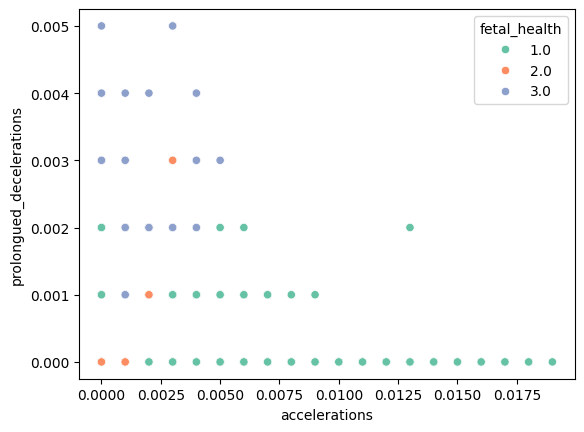

In [14]:
sns.scatterplot(data=df, x="accelerations", y="prolongued_decelerations", hue="fetal_health", palette="Set2")
plt.show()

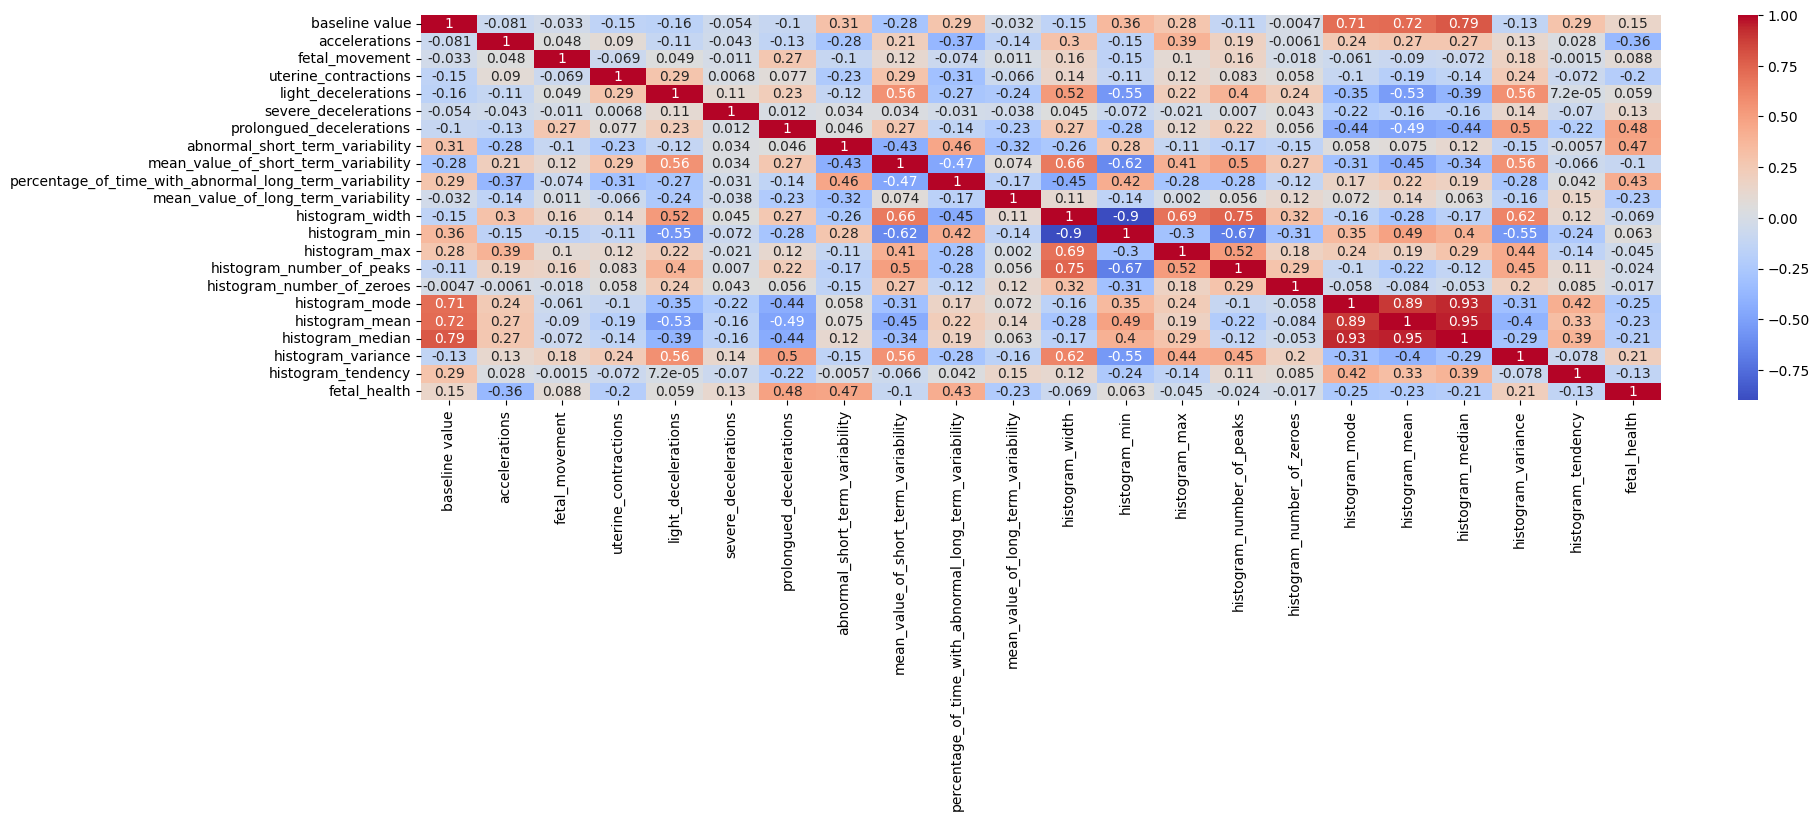

In [15]:
plt.figure(figsize=(20,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [16]:
drop_cols = [
    "histogram_width",
    "histogram_min",
    "histogram_max",
    "histogram_number_of_peaks",
    "histogram_number_of_zeroes",
    "histogram_mode",
    "histogram_mean",
    "histogram_median",
    "histogram_variance",
    "histogram_tendency"
]

df = df.drop(drop_cols, axis=1)

In [17]:
print(df.shape)
df.describe()

(2126, 12)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,3.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 12 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [19]:
# dependent & independent features
X = df.drop("fetal_health", axis=1).values
y = df["fetal_health"].values - 1

In [20]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
len(X_train), len(X_test), len(y_train), len(y_test)

(1700, 426, 1700, 426)

In [22]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#!pip install torchmetrics

In [24]:
import torch
from torch import nn

from torchmetrics.classification import MulticlassAccuracy

In [25]:
X_train

array([[-0.00884342, -0.8301072 , -0.2071137 , ...,  1.90749425,
        -0.53840522, -1.49046799],
       [ 1.32067793,  0.72834917, -0.2071137 , ..., -0.38387109,
        -0.53840522,  0.11527889],
       [-0.41792691, -0.8301072 , -0.18626621, ...,  2.13663078,
        -0.53840522, -1.49046799],
       ...,
       [-0.52019779, -0.8301072 , -0.2071137 , ..., -0.95671242,
        -0.53840522, -0.24966358],
       [-0.52019779, -0.8301072 ,  6.75594848, ...,  1.33465291,
        -0.53840522, -0.76058304],
       [-1.03155215, -0.05087902, -0.14457122, ..., -0.61300762,
        -0.43022144,  1.31958904]])

In [26]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [27]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([1700, 11]) torch.Size([426, 11])
torch.Size([1700]) torch.Size([426])


In [28]:
class ClassificationModel(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Linear(11, 20),
        nn.ReLU(),
        #nn.Dropout(0.2),

        nn.Linear(20, 20),

        nn.ReLU(),
        #nn.Dropout(0.2),

        nn.Linear(20, 3)
      )

  def forward(self, x):
    return self.layer_stack(x)

In [29]:
torch.manual_seed(42)

model = ClassificationModel()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [30]:
epochs = 120

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

accuracy = MulticlassAccuracy(num_classes=3)

for epoch in range(epochs):
  model.train()

  logits = model(X_train)
  loss = loss_fn(logits, y_train)

  pred = torch.softmax(logits, dim=1).argmax(dim=1)
  acc = accuracy(pred, y_train).item() * 100

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_losses.append(loss.item())
  train_accuracies.append(acc)

  model.eval()

  with torch.inference_mode():
    test_logits = model(X_test)
    test_loss = loss_fn(test_logits, y_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_acc = accuracy(test_pred, y_test).item() * 100

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

  if epoch % 10 == 0:
     print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1576 | Acc: 35.58% | Test Loss: 1.1075 | Test Acc: 40.30%
Epoch 10 | Loss: 0.5741 | Acc: 33.33% | Test Loss: 0.5555 | Test Acc: 33.33%
Epoch 20 | Loss: 0.3757 | Acc: 60.19% | Test Loss: 0.4006 | Test Acc: 54.72%
Epoch 30 | Loss: 0.2991 | Acc: 75.08% | Test Loss: 0.3477 | Test Acc: 64.87%
Epoch 40 | Loss: 0.2681 | Acc: 79.80% | Test Loss: 0.3411 | Test Acc: 71.11%
Epoch 50 | Loss: 0.2456 | Acc: 80.28% | Test Loss: 0.3229 | Test Acc: 69.87%
Epoch 60 | Loss: 0.2272 | Acc: 81.07% | Test Loss: 0.3022 | Test Acc: 72.07%
Epoch 70 | Loss: 0.2120 | Acc: 80.81% | Test Loss: 0.3049 | Test Acc: 71.12%
Epoch 80 | Loss: 0.1978 | Acc: 81.99% | Test Loss: 0.2964 | Test Acc: 74.34%
Epoch 90 | Loss: 0.1826 | Acc: 84.05% | Test Loss: 0.2870 | Test Acc: 73.88%
Epoch 100 | Loss: 0.1675 | Acc: 85.54% | Test Loss: 0.2807 | Test Acc: 75.31%
Epoch 110 | Loss: 0.1543 | Acc: 87.52% | Test Loss: 0.2826 | Test Acc: 81.38%


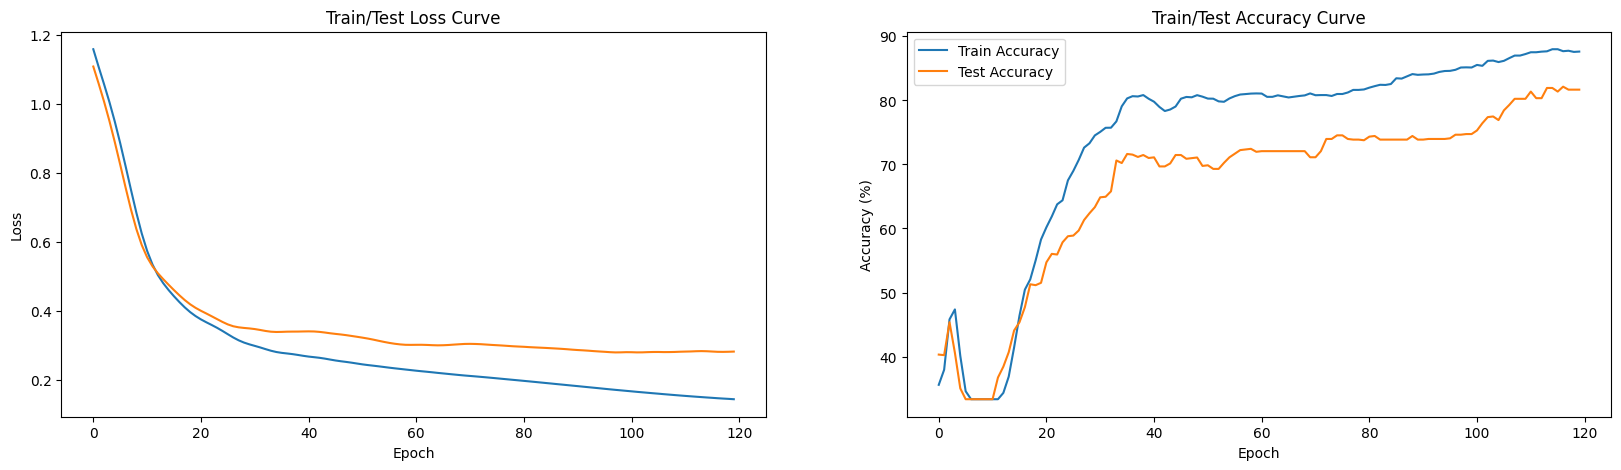

In [31]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")

plt.legend()
plt.show()

In [32]:
new_sample = np.array([[
    120.0,   # baseline value
    0.003,   # accelerations
    0.000,   # fetal_movement
    0.004,   # uterine_contractions
    0.000,   # light_decelerations
    0.000,   # severe_decelerations
    0.000,   # prolongued_decelerations
    25.0,    # abnormal_short_term_variability
    1.5,     # mean_value_of_short_term_variability
    5.0,     # percentage_of_time_with_abnormal_long_term_variability
    10.0     # mean_value_of_long_term_variability
]])

In [33]:
new_sample_scaled = scaler.transform(new_sample)
new_sample_tensor = torch.tensor(new_sample_scaled, dtype=torch.float32)

In [34]:
new_sample_tensor.shape

torch.Size([1, 11])

In [35]:
model.eval()
with torch.inference_mode():
  logits = model(new_sample_tensor)
  probs = torch.softmax(logits, dim=1)
  predicted_class = torch.argmax(probs, dim=1).item()

In [36]:
class_names = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

predicted_label = class_names[predicted_class]

print("Predicted Class Index:", predicted_class)
print("Predicted Label:", predicted_label)

Predicted Class Index: 0
Predicted Label: Normal


In [37]:
from torchmetrics.classification import MulticlassConfusionMatrix
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

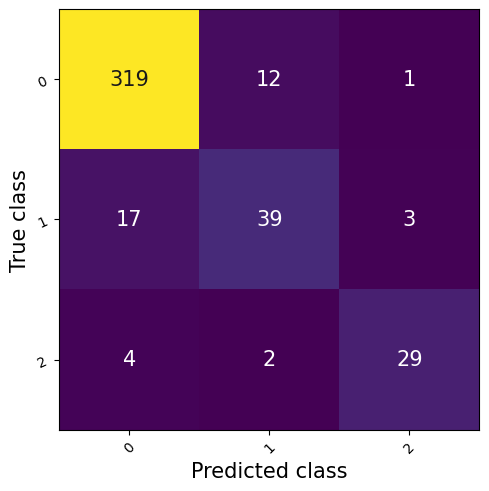

In [38]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)
plot_confusion_matrix(matrix)

In [39]:
# modeli kaydet
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "fetal_health_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [40]:
model.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[-0.0110,  0.6925,  0.1801,  0.1250, -0.0556, -0.1289, -0.5450,  0.3040,
                        0.3515, -0.5394,  0.0029],
                      [-0.3439,  0.4298, -0.0319,  0.2525, -0.3185,  0.0542, -0.0049,  0.3895,
                        0.0537, -0.4246,  0.1288],
                      [ 0.1496,  0.6569, -0.0622, -0.2355,  0.2006, -0.4222, -0.1272, -0.8135,
                        0.3756, -0.3884, -0.0255],
                      [-0.0079, -0.4633,  0.3710, -0.6880,  0.1601,  0.2590, -0.1424,  0.2123,
                       -0.2191, -0.0551,  0.4855],
                      [ 0.4806, -0.1411, -0.0345, -0.4520, -0.2442, -0.0961, -0.2234,  0.3182,
                       -0.4303,  0.3570,  0.0789],
                      [-0.0363,  0.2438, -0.1826,  0.4185, -0.4373, -0.3216, -0.7078, -0.2772,
                       -0.2303,  0.0562, -0.1799],
                      [-0.7512,  0.2221, -0.5308,  0.3078,  0.5350,  0.2338,  0.1695, 

In [41]:
loaded_model = ClassificationModel()

In [42]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [43]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [44]:
# aynı şekilde scaler'ı da kaydediyoruz
import joblib

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [45]:
scaler = joblib.load("models/scaler.pkl")

In [46]:
new_sample = np.array([[
    120.0,
    0.003,
    0.000,
    0.004,
    0.000,
    0.000,
    0.000,
    25.0,
    1.5,
    5.0,
    10.0
]])

new_sample_scaled = scaler.transform(new_sample)
new_sample_tensor = torch.tensor(new_sample_scaled, dtype=torch.float32)

In [47]:
loaded_model.eval()

with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

class_names = {
    0: "Normal",
    1: "Suspect",
    2: "Pathological"
}

predicted_label = class_names[predicted_class]

print("Predicted Class Index:", predicted_class)
print("Predicted Label:", predicted_label)

print("\nClass Probabilities:")
for class_index, probability in enumerate(probs.squeeze()):
    print(f"{class_names[class_index]}: {probability.item() * 100:.4f}%")

Predicted Class Index: 0
Predicted Label: Normal

Class Probabilities:
Normal: 99.9993%
Suspect: 0.0007%
Pathological: 0.0000%
